Device: cuda
Sample: p225_001_mic1.pt
Input shapes: content=(1, 102, 768), speaker=(1, 192), prosody=(1, 102, 3), truth=(102, 80)
Checkpoints found: 3

Rank by validation loss
epoch | train_loss | val_loss | sample_L1 | sample_median | postnet_gain | pred_std/truth_std
   10 | 0.9932 | 0.6046 | 0.7463 | 0.6198 | -0.0003 | 1.8989/2.0407
   11 | 0.9754 | 0.6102 | 0.7133 | 0.5696 | +0.0001 | 1.9700/2.0407
    9 | 1.0211 | 0.6173 | 0.7743 | 0.6651 | -0.0016 | 2.0313/2.0407

Rank by fixed-sample L1
epoch 11: sample_L1=0.7133, val=0.6102
epoch 10: sample_L1=0.7463, val=0.6046
epoch  9: sample_L1=0.7743, val=0.6173

Best by validation: model_checkpoints\decoder_w_features_epoch_0010.pt | epoch 10 | val 0.6046 | sample L1 0.7463
Best on this sample: model_checkpoints\decoder_w_features_epoch_0011.pt | epoch 11 | val 0.6102 | sample L1 0.7133
Plotting validation-best checkpoint: epoch 10


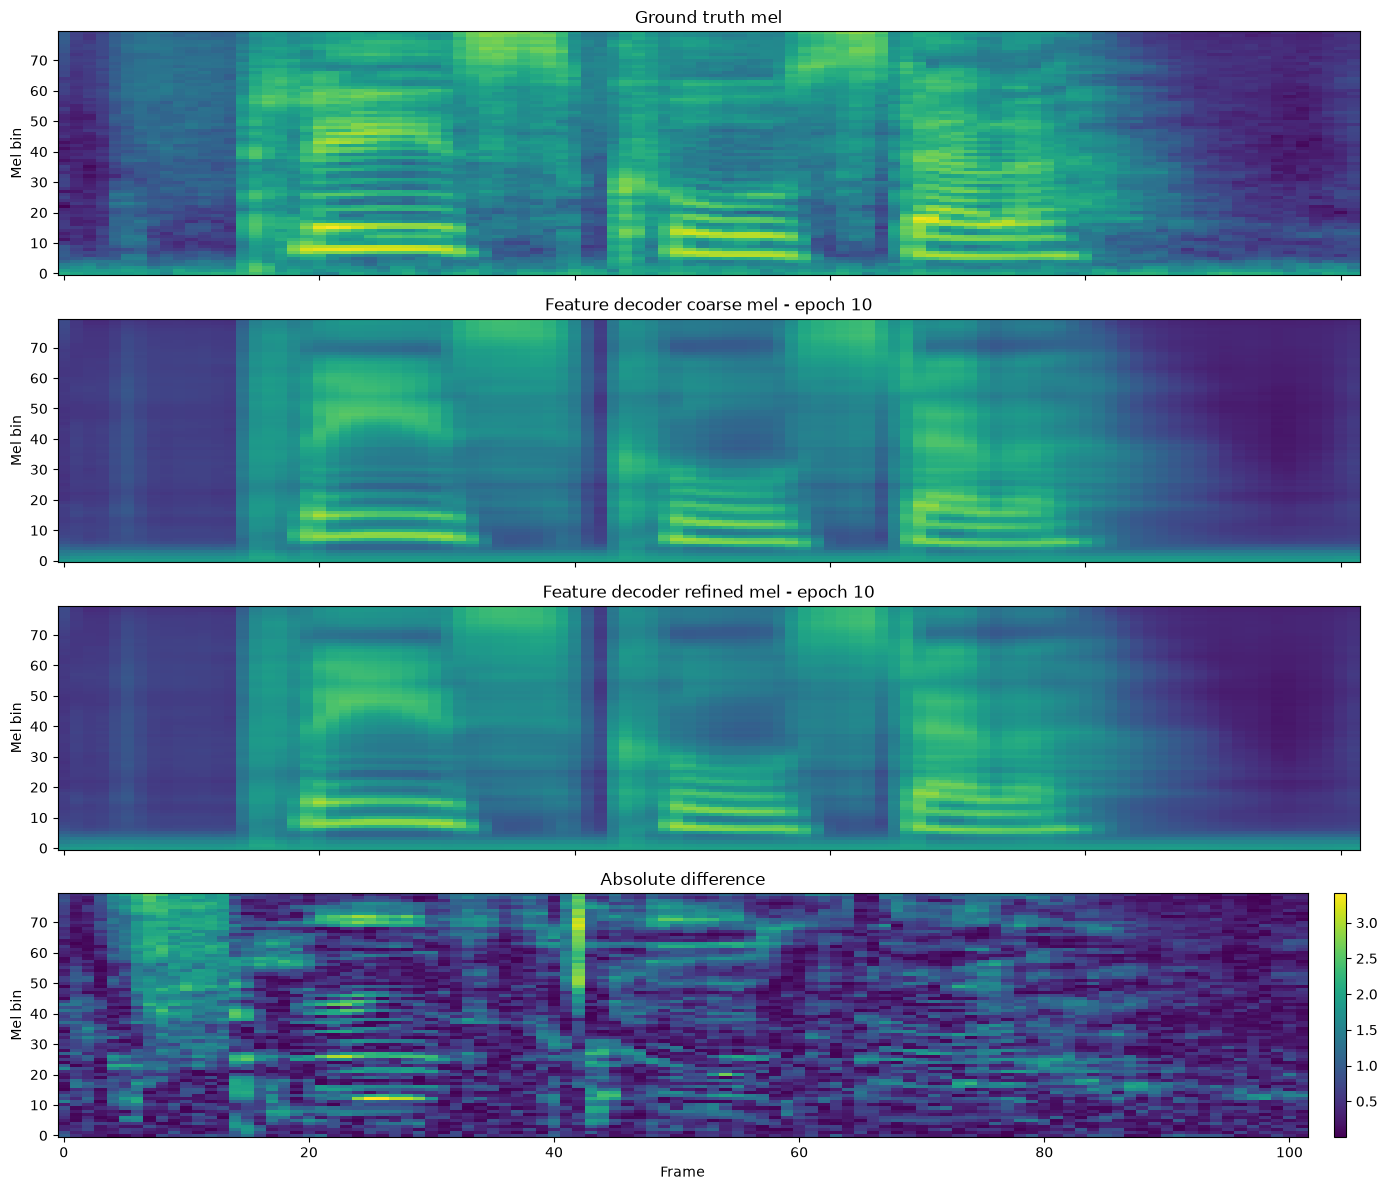

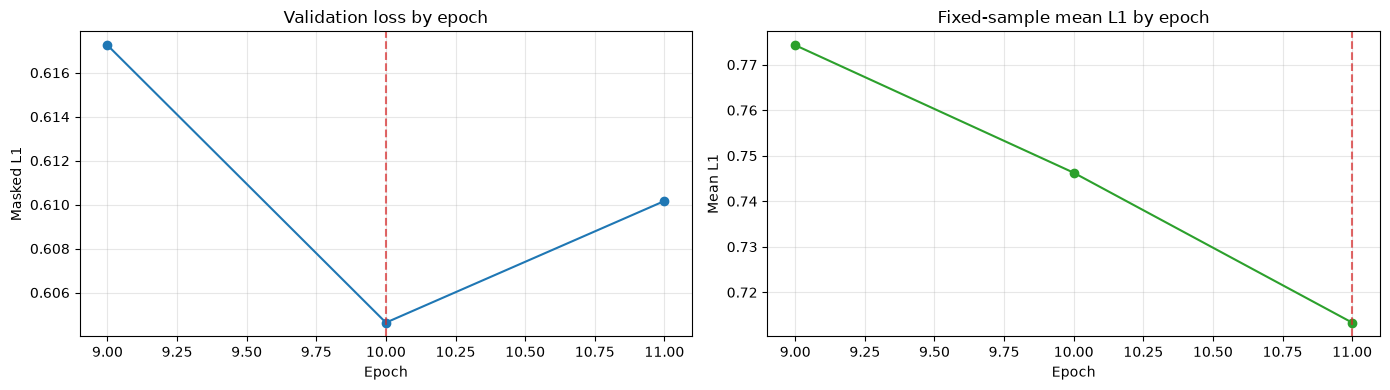

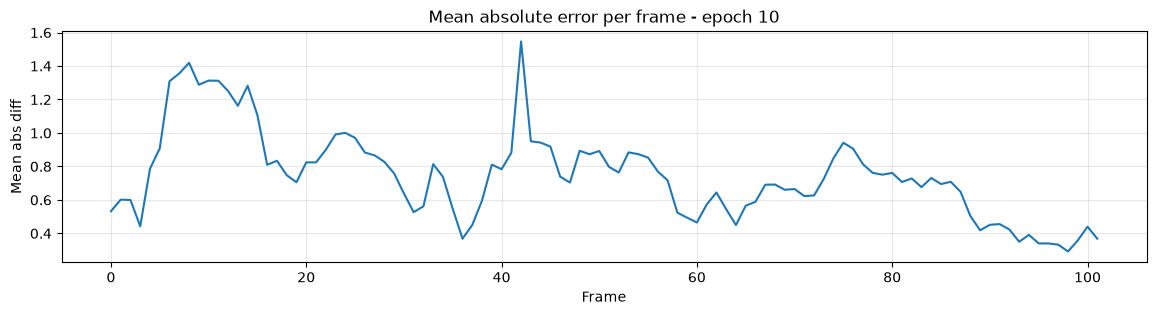

In [4]:
from pathlib import Path
import importlib
import math

import matplotlib.pyplot as plt
import torch

import prepared_datasets.vc_dataset as vc_dataset
vc_dataset = importlib.reload(vc_dataset)
import decoder_w_features as decoder_w_features
decoder_w_features = importlib.reload(decoder_w_features)

VCFeatureDecoder = decoder_w_features.VCFeatureDecoder
load_content_latent = vc_dataset.load_content_latent
squeeze_content = vc_dataset.squeeze_content
squeeze_mel = vc_dataset.squeeze_mel
squeeze_prosody = vc_dataset.squeeze_prosody
squeeze_speaker = vc_dataset.squeeze_speaker


def load_sample(sample_id, device):
    content_payload = torch.load(Path("datasets/precomputed/contents") / sample_id, map_location="cpu")
    speaker_payload = torch.load(Path("datasets/precomputed/speakers") / sample_id, map_location="cpu")
    truth_payload = torch.load(Path("datasets/precomputed/mels") / sample_id, map_location="cpu")
    prosody_payload = torch.load(Path("datasets/precomputed/prosody") / sample_id, map_location="cpu")

    content = squeeze_content(load_content_latent(content_payload, sample_id))
    speaker = squeeze_speaker(speaker_payload["speaker_latent"])
    truth_mel = squeeze_mel(truth_payload["mel"])
    prosody = squeeze_prosody(prosody_payload["prosody"])

    time_steps = min(content.size(0), truth_mel.size(0), prosody.size(0))
    content = content[:time_steps].unsqueeze(0).to(device)
    speaker = speaker.unsqueeze(0).to(device)
    truth_mel = truth_mel[:time_steps].to(device)
    prosody = prosody[:time_steps].unsqueeze(0).to(device)
    return content, speaker, prosody, truth_mel


def evaluate_checkpoint(checkpoint_path, content, speaker, prosody, truth_mel, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    decoder = VCFeatureDecoder().to(device)
    decoder.load_state_dict(checkpoint["model_state_dict"])
    decoder.eval()

    with torch.no_grad():
        coarse_mel, pred_mel = decoder(content, speaker, prosody, return_coarse=True)
        coarse_mel = coarse_mel.squeeze(0)
        pred_mel = pred_mel.squeeze(0)

    abs_diff = (pred_mel - truth_mel).abs()
    coarse_abs_diff = (coarse_mel - truth_mel).abs()
    return {
        "checkpoint_path": checkpoint_path,
        "epoch": int(checkpoint.get("epoch", 0)),
        "train_loss": checkpoint.get("train_loss"),
        "val_loss": checkpoint.get("val_loss"),
        "sample_mean_l1": abs_diff.mean().item(),
        "sample_median_l1": abs_diff.median().item(),
        "coarse_sample_mean_l1": coarse_abs_diff.mean().item(),
        "postnet_gain": coarse_abs_diff.mean().item() - abs_diff.mean().item(),
        "pred_std": pred_mel.std().item(),
        "truth_std": truth_mel.std().item(),
        "coarse_mel": coarse_mel.detach().cpu(),
        "pred_mel": pred_mel.detach().cpu(),
        "truth_mel": truth_mel.detach().cpu(),
        "abs_diff": abs_diff.detach().cpu(),
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_paths = sorted(Path("model_checkpoints").glob("decoder_w_features_epoch_*.pt"))
sample_id = "p225_001_mic1.pt"

if not checkpoint_paths:
    raise FileNotFoundError("No decoder_w_features_epoch_*.pt checkpoints found in model_checkpoints/.")

content, speaker, prosody, truth_mel_device = load_sample(sample_id, device)
results = [evaluate_checkpoint(path, content, speaker, prosody, truth_mel_device, device) for path in checkpoint_paths]
results_by_val = sorted(results, key=lambda item: item["val_loss"] if item["val_loss"] is not None else math.inf)
results_by_sample = sorted(results, key=lambda item: item["sample_mean_l1"])
best_val = results_by_val[0]
best_sample = results_by_sample[0]
selected = best_val

print(f"Device: {device}")
print(f"Sample: {sample_id}")
print(f"Input shapes: content={tuple(content.shape)}, speaker={tuple(speaker.shape)}, prosody={tuple(prosody.shape)}, truth={tuple(truth_mel_device.shape)}")
print(f"Checkpoints found: {len(checkpoint_paths)}")
print()
print("Rank by validation loss")
print("epoch | train_loss | val_loss | sample_L1 | sample_median | postnet_gain | pred_std/truth_std")
for item in results_by_val:
    print(
        f"{item['epoch']:>5} | "
        f"{item['train_loss']:.4f} | "
        f"{item['val_loss']:.4f} | "
        f"{item['sample_mean_l1']:.4f} | "
        f"{item['sample_median_l1']:.4f} | "
        f"{item['postnet_gain']:+.4f} | "
        f"{item['pred_std']:.4f}/{item['truth_std']:.4f}"
    )

print()
print("Rank by fixed-sample L1")
for item in results_by_sample:
    print(f"epoch {item['epoch']:>2}: sample_L1={item['sample_mean_l1']:.4f}, val={item['val_loss']:.4f}")

print()
print(f"Best by validation: {best_val['checkpoint_path']} | epoch {best_val['epoch']} | val {best_val['val_loss']:.4f} | sample L1 {best_val['sample_mean_l1']:.4f}")
print(f"Best on this sample: {best_sample['checkpoint_path']} | epoch {best_sample['epoch']} | val {best_sample['val_loss']:.4f} | sample L1 {best_sample['sample_mean_l1']:.4f}")
print(f"Plotting validation-best checkpoint: epoch {selected['epoch']}")

truth_mel = selected["truth_mel"]
coarse_mel = selected["coarse_mel"]
pred_mel = selected["pred_mel"]
abs_diff = selected["abs_diff"]

vmin = min(truth_mel.min().item(), coarse_mel.min().item(), pred_mel.min().item())
vmax = max(truth_mel.max().item(), coarse_mel.max().item(), pred_mel.max().item())

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].imshow(truth_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth mel")
axes[0].set_ylabel("Mel bin")

axes[1].imshow(coarse_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Feature decoder coarse mel - epoch {selected['epoch']}")
axes[1].set_ylabel("Mel bin")

axes[2].imshow(pred_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[2].set_title(f"Feature decoder refined mel - epoch {selected['epoch']}")
axes[2].set_ylabel("Mel bin")

diff_image = axes[3].imshow(abs_diff.T, aspect="auto", origin="lower")
axes[3].set_title("Absolute difference")
axes[3].set_xlabel("Frame")
axes[3].set_ylabel("Mel bin")
fig.colorbar(diff_image, ax=axes[3], fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

epochs = [item["epoch"] for item in results]
val_losses = [item["val_loss"] for item in results]
sample_losses = [item["sample_mean_l1"] for item in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(epochs, val_losses, marker="o")
axes[0].axvline(best_val["epoch"], color="tab:red", linestyle="--", alpha=0.7)
axes[0].set_title("Validation loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Masked L1")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, sample_losses, marker="o", color="tab:green")
axes[1].axvline(best_sample["epoch"], color="tab:red", linestyle="--", alpha=0.7)
axes[1].set_title("Fixed-sample mean L1 by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean L1")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(abs_diff.mean(dim=1))
plt.title(f"Mean absolute error per frame - epoch {selected['epoch']}")
plt.xlabel("Frame")
plt.ylabel("Mean abs diff")
plt.grid(alpha=0.3)
plt.show()


Samples evaluated: 5/5
Checkpoints evaluated: 3

Aggregate rank by frame-weighted sample L1
epoch | val_loss | weighted_L1 | mean_sample_L1 | median_L1 | postnet_gain | wins | pred_std/truth_std
   11 | 0.6102 | 0.6485 | 0.6503 | 0.5042 | +0.0005 |    3 | 2.0597/2.1266
   10 | 0.6046 | 0.6734 | 0.6831 | 0.5377 | +0.0013 |    2 | 1.9858/2.1266
    9 | 0.6173 | 0.6889 | 0.6907 | 0.5538 | -0.0006 |    0 | 2.1007/2.1266

Per-sample rank
p225_001_mic1.pt
  epoch 11: sample_L1=0.7133, median=0.5696, gain=+0.0001, val=0.6102
  epoch 10: sample_L1=0.7463, median=0.6198, gain=-0.0003, val=0.6046
  epoch  9: sample_L1=0.7743, median=0.6651, gain=-0.0016, val=0.6173
p226_001_mic1.pt
  epoch 11: sample_L1=0.7643, median=0.6474, gain=+0.0031, val=0.6102
  epoch 10: sample_L1=0.7789, median=0.6803, gain=+0.0046, val=0.6046
  epoch  9: sample_L1=0.8225, median=0.7061, gain=+0.0001, val=0.6173
p227_001_mic1.pt
  epoch 10: sample_L1=0.5644, median=0.4362, gain=+0.0011, val=0.6046
  epoch 11: sample_L1=

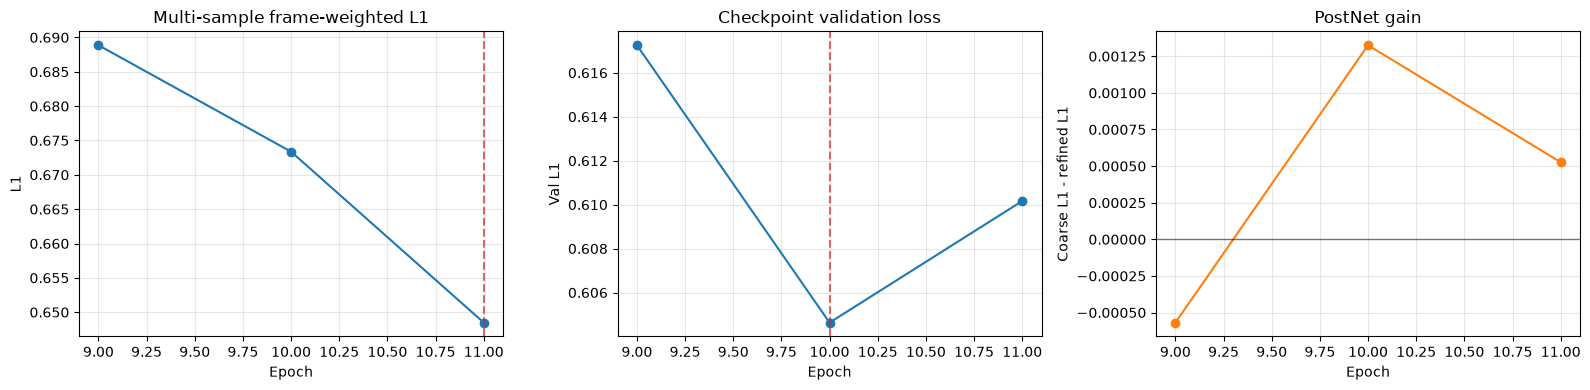

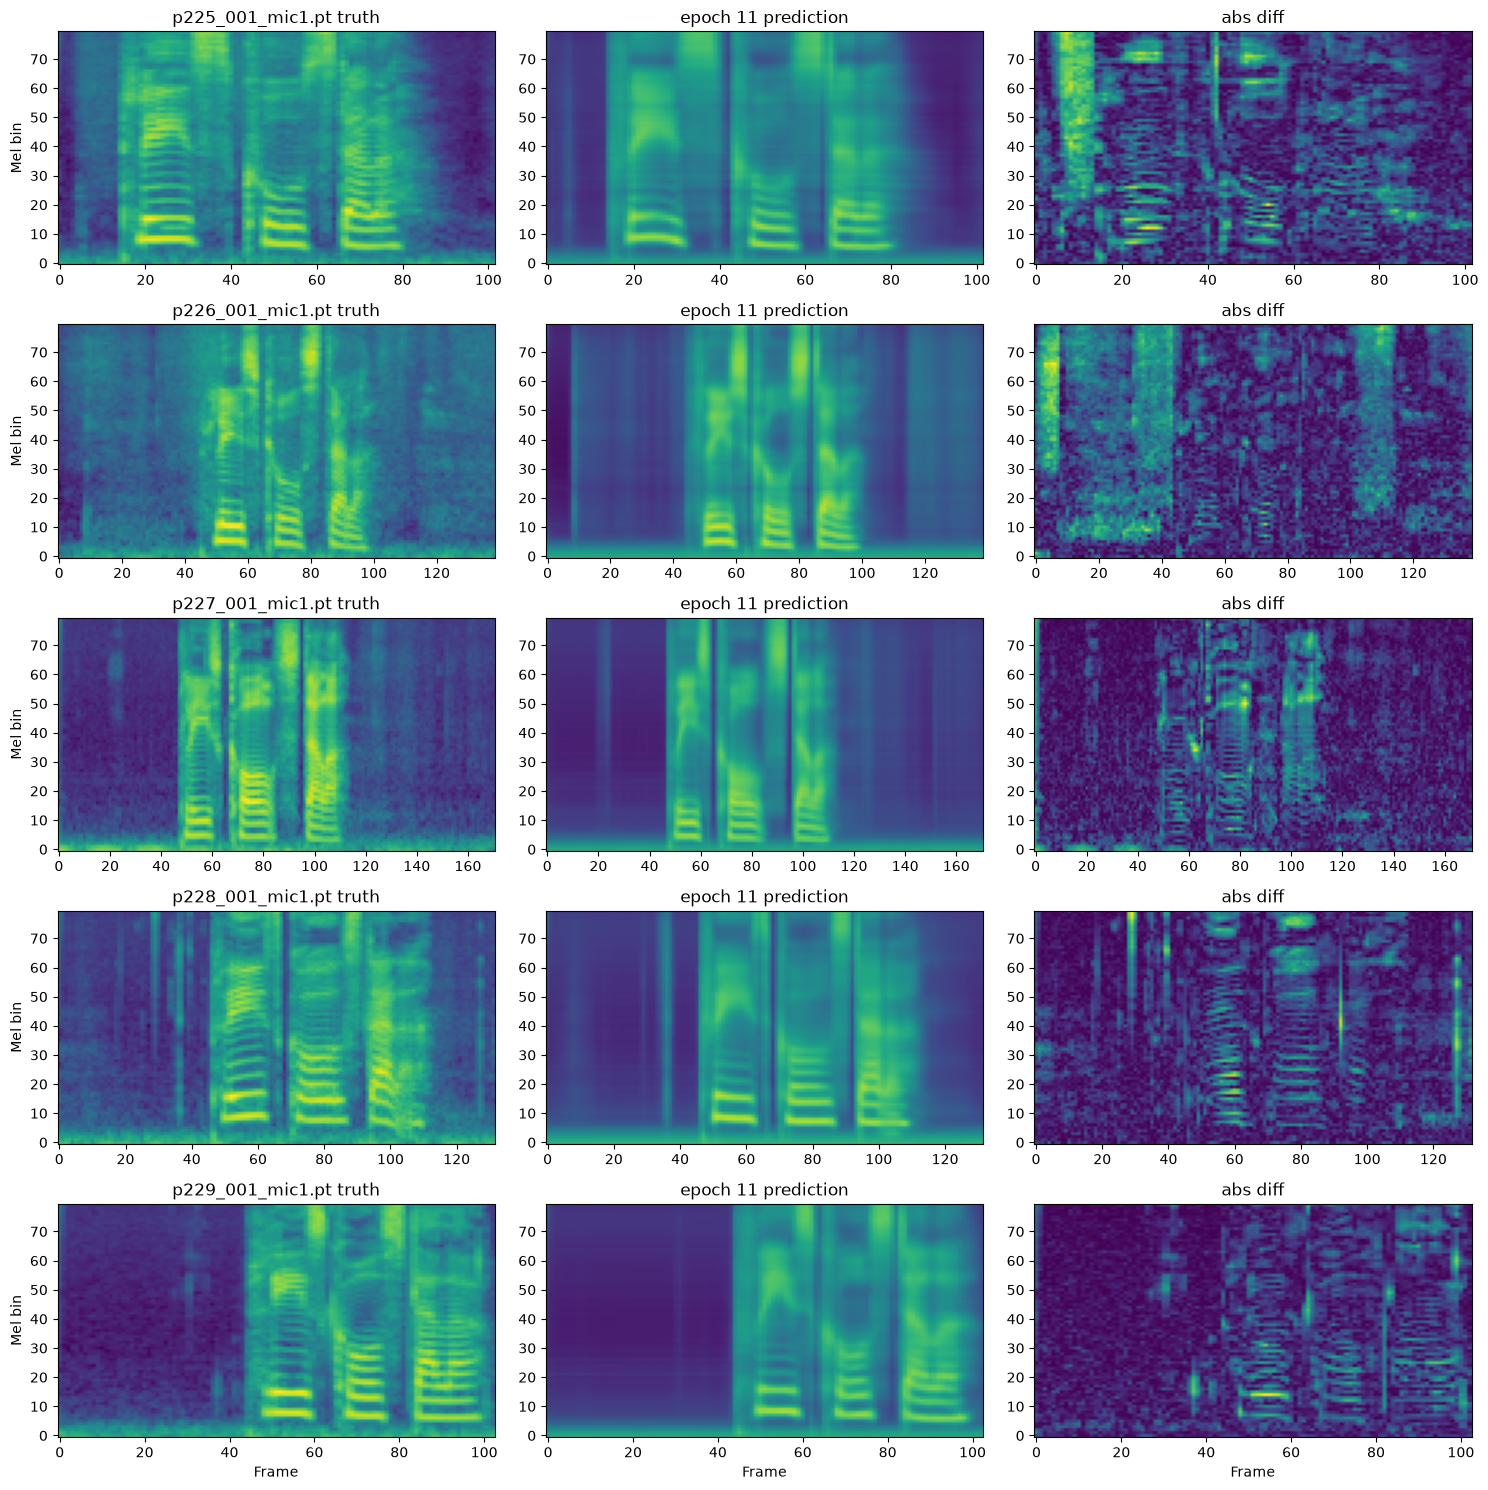

In [5]:
sample_ids = [
    "p225_001_mic1.pt",
    "p226_001_mic1.pt",
    "p227_001_mic1.pt",
    "p228_001_mic1.pt",
    "p229_001_mic1.pt",
]

multi_results = []
missing_samples = []

for sample_id in sample_ids:
    try:
        content, speaker, prosody, truth_mel_device = load_sample(sample_id, device)
    except FileNotFoundError as error:
        missing_samples.append((sample_id, str(error)))
        continue

    for checkpoint_path in checkpoint_paths:
        result = evaluate_checkpoint(checkpoint_path, content, speaker, prosody, truth_mel_device, device)
        result = {
            key: value
            for key, value in result.items()
            if key not in {"coarse_mel", "pred_mel", "truth_mel", "abs_diff"}
        }
        result["sample_id"] = sample_id
        result["frames"] = int(truth_mel_device.size(0))
        multi_results.append(result)

if missing_samples:
    print("Missing samples")
    for sample_id, error in missing_samples:
        print(f"{sample_id}: {error}")
    print()

if not multi_results:
    raise RuntimeError("No multi-sample results were computed.")

epochs = sorted({item["epoch"] for item in multi_results})
summary = []

for epoch in epochs:
    epoch_items = [item for item in multi_results if item["epoch"] == epoch]
    total_frames = sum(item["frames"] for item in epoch_items)
    frame_weighted_l1 = sum(item["sample_mean_l1"] * item["frames"] for item in epoch_items) / total_frames
    frame_weighted_coarse_l1 = sum(item["coarse_sample_mean_l1"] * item["frames"] for item in epoch_items) / total_frames
    frame_weighted_postnet_gain = frame_weighted_coarse_l1 - frame_weighted_l1

    summary.append({
        "epoch": epoch,
        "checkpoint_path": epoch_items[0]["checkpoint_path"],
        "train_loss": epoch_items[0]["train_loss"],
        "val_loss": epoch_items[0]["val_loss"],
        "num_samples": len(epoch_items),
        "total_frames": total_frames,
        "mean_sample_l1": sum(item["sample_mean_l1"] for item in epoch_items) / len(epoch_items),
        "mean_sample_median_l1": sum(item["sample_median_l1"] for item in epoch_items) / len(epoch_items),
        "frame_weighted_l1": frame_weighted_l1,
        "frame_weighted_coarse_l1": frame_weighted_coarse_l1,
        "frame_weighted_postnet_gain": frame_weighted_postnet_gain,
        "mean_pred_std": sum(item["pred_std"] for item in epoch_items) / len(epoch_items),
        "mean_truth_std": sum(item["truth_std"] for item in epoch_items) / len(epoch_items),
        "wins": 0,
    })

for sample_id in sample_ids:
    sample_items = [item for item in multi_results if item["sample_id"] == sample_id]
    if not sample_items:
        continue
    winning_item = min(sample_items, key=lambda item: item["sample_mean_l1"])
    for item in summary:
        if item["epoch"] == winning_item["epoch"]:
            item["wins"] += 1

summary_by_l1 = sorted(summary, key=lambda item: item["frame_weighted_l1"])
summary_by_val = sorted(summary, key=lambda item: item["val_loss"] if item["val_loss"] is not None else math.inf)
best_multi = summary_by_l1[0]
best_val_multi = summary_by_val[0]

print(f"Samples evaluated: {len(set(item['sample_id'] for item in multi_results))}/{len(sample_ids)}")
print(f"Checkpoints evaluated: {len(epochs)}")
print()
print("Aggregate rank by frame-weighted sample L1")
print("epoch | val_loss | weighted_L1 | mean_sample_L1 | median_L1 | postnet_gain | wins | pred_std/truth_std")
for item in summary_by_l1:
    print(
        f"{item['epoch']:>5} | "
        f"{item['val_loss']:.4f} | "
        f"{item['frame_weighted_l1']:.4f} | "
        f"{item['mean_sample_l1']:.4f} | "
        f"{item['mean_sample_median_l1']:.4f} | "
        f"{item['frame_weighted_postnet_gain']:+.4f} | "
        f"{item['wins']:>4} | "
        f"{item['mean_pred_std']:.4f}/{item['mean_truth_std']:.4f}"
    )

print()
print("Per-sample rank")
for sample_id in sample_ids:
    sample_items = sorted(
        [item for item in multi_results if item["sample_id"] == sample_id],
        key=lambda item: item["sample_mean_l1"],
    )
    if not sample_items:
        continue
    print(sample_id)
    for item in sample_items:
        print(
            f"  epoch {item['epoch']:>2}: "
            f"sample_L1={item['sample_mean_l1']:.4f}, "
            f"median={item['sample_median_l1']:.4f}, "
            f"gain={item['postnet_gain']:+.4f}, "
            f"val={item['val_loss']:.4f}"
        )

print()
print(f"Best aggregate sample checkpoint: {best_multi['checkpoint_path']} | epoch {best_multi['epoch']} | weighted L1 {best_multi['frame_weighted_l1']:.4f}")
print(f"Best validation checkpoint: {best_val_multi['checkpoint_path']} | epoch {best_val_multi['epoch']} | val {best_val_multi['val_loss']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epoch_values = [item["epoch"] for item in summary]
axes[0].plot(epoch_values, [item["frame_weighted_l1"] for item in summary], marker="o")
axes[0].axvline(best_multi["epoch"], color="tab:red", linestyle="--", alpha=0.7)
axes[0].set_title("Multi-sample frame-weighted L1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L1")
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_values, [item["val_loss"] for item in summary], marker="o", color="tab:blue")
axes[1].axvline(best_val_multi["epoch"], color="tab:red", linestyle="--", alpha=0.7)
axes[1].set_title("Checkpoint validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val L1")
axes[1].grid(alpha=0.3)

axes[2].plot(epoch_values, [item["frame_weighted_postnet_gain"] for item in summary], marker="o", color="tab:orange")
axes[2].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[2].set_title("PostNet gain")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Coarse L1 - refined L1")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_epoch = best_multi["epoch"]
plot_checkpoint = best_multi["checkpoint_path"]
plot_rows = len(sample_ids)
fig, axes = plt.subplots(plot_rows, 3, figsize=(15, 3 * plot_rows), squeeze=False)

for row, sample_id in enumerate(sample_ids):
    content, speaker, prosody, truth_mel_device = load_sample(sample_id, device)
    full_result = evaluate_checkpoint(plot_checkpoint, content, speaker, prosody, truth_mel_device, device)
    truth_mel = full_result["truth_mel"]
    pred_mel = full_result["pred_mel"]
    abs_diff = full_result["abs_diff"]
    vmin = min(truth_mel.min().item(), pred_mel.min().item())
    vmax = max(truth_mel.max().item(), pred_mel.max().item())

    axes[row, 0].imshow(truth_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"{sample_id} truth")
    axes[row, 0].set_ylabel("Mel bin")

    axes[row, 1].imshow(pred_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"epoch {plot_epoch} prediction")

    axes[row, 2].imshow(abs_diff.T, aspect="auto", origin="lower")
    axes[row, 2].set_title("abs diff")

for axis in axes[-1, :]:
    axis.set_xlabel("Frame")

plt.tight_layout()
plt.show()
